This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

2024-05-29 15:44:49.480979: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-29 15:44:49.482817: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-29 15:44:49.509194: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-29 15:44:49.509220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-29 15:44:49.509864: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_results(results, labels, print_label='Experiment'):
# Define the custom palette
    custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

    label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']


    # Assuming 'print_label' is the column name for experiments
    experiment_column = labels[print_label].values
    results[print_label] = experiment_column
    print(results)

    # Create scatter plot with custom palette
    sns.scatterplot(x='Actual', y='Predicted', hue=print_label, data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.gca().set_ylim(bottom=15, top=100)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

In [3]:
fit=False

In [4]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Experiment,Sample
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,71.0,GSE157585,SRR12604093
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,77.0,GSE167186,SRR13758996
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,58.0,GSE129643,SRR8882184
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0,GSE157585,SRR12604092
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0,GSE164471,SRR13388738


In [5]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.0860871588773362


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


376

In [6]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Age")


In [7]:
eigth_bins_filteres = eigth_bins[rnaseq_genes]


In [8]:
del eigth_bins

In [9]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
if isinstance(seq_y_train_cat_a[0], str):
    seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
    seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)
else:
    seq_y_train_a = seq_y_train_cat_a

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)

dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000252287.1,ENSG00000211844.1,ENSG00000189058.8,ENSG00000270388.1,ENSG00000252456.1,ENSG00000212571.1,ENSG00000199455.1,ENSG00000004866.20,ENSG00000255633.5,ENSG00000198840.2,...,ENSG00000134278.15,ENSG00000133104.12,ENSG00000146007.10,ENSG00000233674.2,ENSG00000266179.2,ENSG00000202047.1,ENSG00000062485.18,ENSG00000183337.16,ENSG00000035664.11,Age
0,-0.028376,-0.031917,-0.020637,-0.027112,-0.024847,-0.032051,-0.025936,-0.021146,-0.032096,36.759524,...,-0.023162,-0.012130,0.059103,-0.027735,0.009502,-0.030629,0.042037,-0.025007,0.032353,72.0
1,-0.024833,-0.025733,-0.016927,-0.025604,-0.021242,-0.025521,-0.023206,-0.016661,-0.025621,33.021326,...,-0.015939,-0.004477,0.035204,-0.022162,0.004591,-0.026582,0.033608,-0.020532,0.017613,78.0
2,-0.029295,-0.027002,-0.026566,-0.019448,-0.022460,-0.027198,-0.033643,-0.016588,-0.027772,35.408788,...,-0.020214,-0.014473,0.037661,-0.022238,-0.054741,-0.025724,0.030609,-0.019188,0.005009,61.0
3,-0.029016,-0.032780,-0.021709,-0.027603,-0.024226,-0.032961,-0.026556,-0.020391,-0.032994,36.122783,...,-0.021104,-0.009008,0.058307,-0.028027,0.007962,-0.031259,0.057817,-0.021784,0.041021,71.0
4,-0.033010,-0.029531,-0.008979,0.143629,-0.034746,-0.030575,-0.036428,-0.018289,-0.030767,33.439804,...,-0.020047,-0.010796,0.039429,-0.028165,-0.013892,-0.028216,0.066683,-0.021601,0.010055,41.0


In [10]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=0.2)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [11]:

optimize = optimize(train_data = dataset, n_trials=20)
#params = optimize.optimize()
#params

In [12]:

if fit:
    x = optimize.optimize()
    print(x)

In [13]:
params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}
#params = {'iterations': 2000, 'learning_rate': 0.00984211577545461, 'depth': 2, 'l2_leaf_reg': 9.709291858633904, 'random_strength': 4.545211685851626, 'min_data_in_leaf': 49, 'score_function': 'Cosine', 'penalties_coefficient': 4.226444903400312, 'model_shrink_rate': 0.28139372449907607}
#params = {'iterations': 2000, 'learning_rate': 0.009859735066518074, 'depth': 4, 'l2_leaf_reg': 5.8874298860436625, 'random_strength': 9.492374563806697, 'min_data_in_leaf': 39, 'score_function': 'Cosine', 'penalties_coefficient': 0.004695591273947031, 'model_shrink_rate': 0.003428442640894508}

In [14]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.3)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

In [15]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_8_Ridge_seq_regressor.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_8_Ridge_seq_regressor.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [16]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

30.306179478217096

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 30.306179478217096
RMSE: 5.505104856241804
MAE: 4.195136377399312
R2: 0.9419757035011481


In [18]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 7},
 {'label': '26-35', 'range': (26, 35), 'count': 9},
 {'label': '35-50', 'range': (35, 50), 'count': 5},
 {'label': '50-65', 'range': (50, 65), 'count': 2},
 {'label': '65-71', 'range': (65, 71), 'count': 7},
 {'label': '71-72', 'range': (71, 72), 'count': 5},
 {'label': '72-95', 'range': (72, 95), 'count': 13}]

In [19]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 4,  3,  0,  0,  0,  0,  0,  0],
       [ 2,  6,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  1,  2,  3,  0],
       [ 0,  0,  0,  0,  3,  0,  2,  0],
       [ 0,  0,  0,  0,  3,  0, 10,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0]])

In [20]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.5510204081632653

In [21]:
y_test

48     79.0
151    71.0
92     73.0
113    16.0
69     33.0
112    68.0
91     78.0
146    27.0
105    24.0
122    25.0
86     54.0
161    84.0
32     27.0
77     26.0
90     36.0
17     74.0
46     34.0
83     71.0
107    86.0
0      72.0
61     46.0
155    76.0
14     22.0
101    23.0
59     29.0
135    72.0
22     67.0
30     39.0
114    21.0
149    70.0
53     26.0
15     67.0
96     38.0
13     70.0
84     71.0
43     72.0
33     71.0
157    67.0
99     81.0
131    71.0
55     74.0
68     20.0
62     27.0
25     70.0
138    83.0
28     46.0
7      57.0
109    21.0
133    26.0
Name: Age, dtype: float64

In [22]:
seq_results

,Actual,Predicted
48,79.0,81.824391
151,71.0,72.148767
92,73.0,79.553529
113,16.0,23.158311
69,33.0,30.366833
112,68.0,72.951372
91,78.0,87.345134
146,27.0,23.695327
105,24.0,25.075052
122,25.0,29.368631


/tmp/ipykernel_16904/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


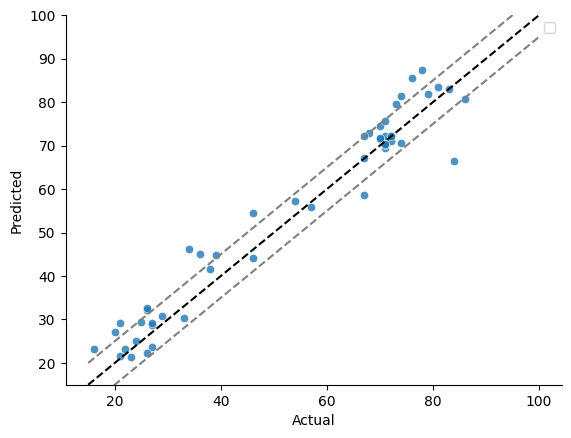

In [23]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [24]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 4,  3,  0,  0,  0,  0,  0,  0],
       [ 2,  6,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  1,  2,  3,  0],
       [ 0,  0,  0,  0,  3,  0,  2,  0],
       [ 0,  0,  0,  0,  3,  0, 10,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0]])

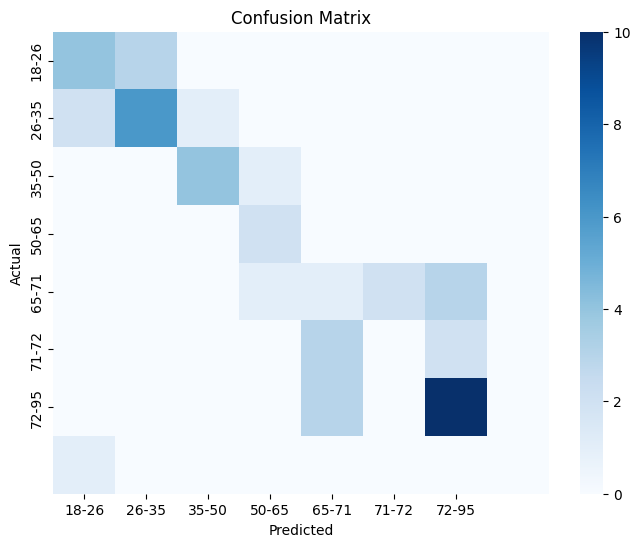

In [25]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_test.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Sample,Experiment,Age
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432,SRR12604218,GSE157585,24.0
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087,SRR13759023,GSE167186,18.0
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776,SRR13759025,GSE167186,23.0
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812,SRR1555206,GSE60590,26.4
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577,SRR12604184,GSE157585,71.0


In [27]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [28]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [29]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [30]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

41.90473323464307

/tmp/ipykernel_16904/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


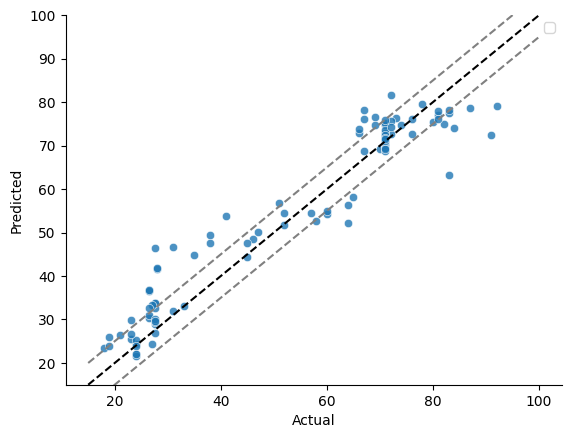

In [31]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

     Actual  Predicted Experiment
0      24.0  24.326454  GSE157585
1      18.0  23.448941  GSE167186
2      23.0  25.515661  GSE167186
3      26.4  36.774748   GSE60590
4      71.0  74.691306  GSE157585
..      ...        ...        ...
103    71.0  71.629130  GSE157585
104    23.0  26.726893  GSE167186
105    72.0  74.304725  GSE164471
106    71.0  71.487631  GSE157585
107    71.0  75.845212  GSE167186

[108 rows x 3 columns]


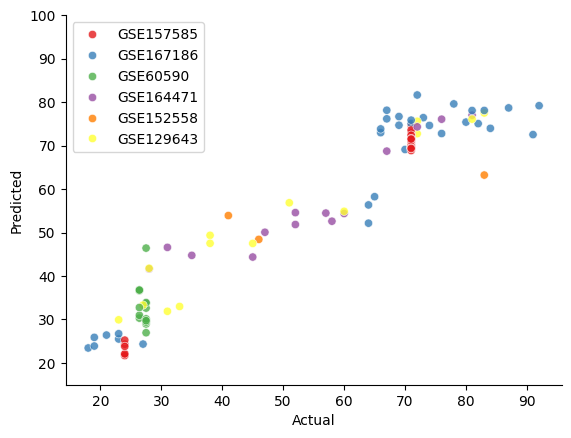

In [32]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [33]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[10,  3,  0,  0,  0,  0,  0],
       [ 1, 15,  7,  0,  0,  0,  0],
       [ 0,  0,  6,  2,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  1,  2,  0,  6],
       [ 0,  0,  0,  0, 10,  8,  7],
       [ 0,  0,  0,  1,  0,  0, 20]])

In [34]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.6481481481481481

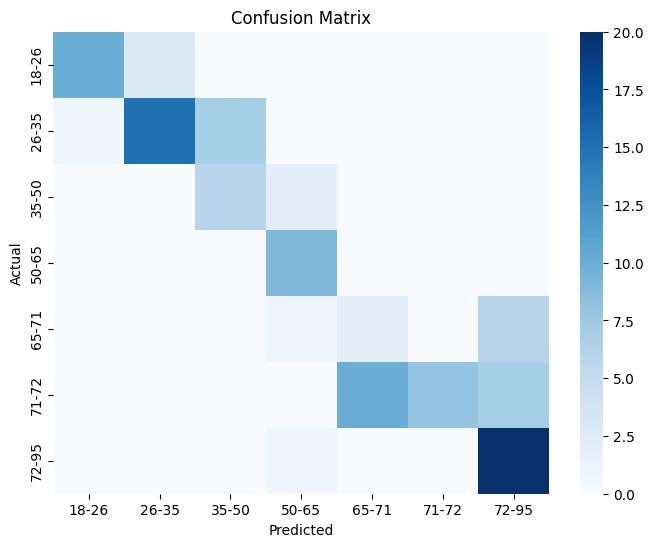

In [35]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("RNAs_z_Combat_2_8_Ridge_seq_confusion_matrix.png")
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 41.90473323464307
RMSE: 6.473386535241278
MAE: 4.748924219045501
R2: 0.9163005099532565


In [41]:
explainer = shap.Explainer(seq_regressor)
shap_values = explainer.shap_values(X_test)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000035664.11,7.812468
ENSG00000160294.10,3.991438
ENSG00000197111.15,2.835594
ENSG00000167186.10,2.725603
ENSG00000250479.8,2.599951
...,...
ENSG00000173334.3,0.008334
ENSG00000201096.1,0.008087
ENSG00000234175.1,0.006415
ENSG00000285268.1,0.005956


In [42]:
feature_imporance_df.head(50)

,importance
ENSG00000035664.11,7.812468
ENSG00000160294.10,3.991438
ENSG00000197111.15,2.835594
ENSG00000167186.10,2.725603
ENSG00000250479.8,2.599951
ENSG00000276045.3,2.450449
ENSG00000105323.16,2.231410
ENSG00000252598.1,2.092847
ENSG00000197563.10,2.008277
ENSG00000164093.16,1.799515


In [43]:
feature_imporance_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_8_Ridge_seq_RIDGE_regressor_genes.csv")

In [46]:
gene_names = [
("ENSG00000101892.11","ATP1B4"),
("ENSG00000201766.1","RNA5SP302"),
("ENSG00000127241.16","MASP1"),
("ENSG00000277654.5","AC087633.2"),
("ENSG00000145949.10","MYLK4"),
("ENSG00000171055.14","FEZ2"),
("ENSG00000198712.1","MT-CO2"),
("ENSG00000164104.11","HMGB2"),
("ENSG00000172399.5","MYOZ2"),
("ENSG00000177548.12","RABEP2"),
("ENSG00000089101.17","CFAP61"),
("ENSG00000003989.17","SLC7A2"),
("ENSG00000137700.17","SLC37A4"),
("ENSG00000174227.15","PIGG"),
("ENSG00000133020.4","MYH8"),
("ENSG00000252262.1","RNA5SP61"),
("ENSG00000234441.1","AC105272.1"),
("ENSG00000247627.2","MTND4P12"),
("ENSG00000100568.10","VTI1B"),
("ENSG00000237973.1","MTCO1P12"),
("ENSG00000170873.18","MTSS1"),
("ENSG00000082397.17"	,"EPB41L3"),
("ENSG00000111640.14"	,"GAPDH"),
    ("ENSG00000035664.11", "DAPK2"),
    ("ENSG00000160294.10", "MCM3AP"),
    ("ENSG00000197111.15", "PCBP2"),
    ("ENSG00000250479.8", "CHCHD10"),
    ("ENSG00000105323.16", "HNRNPUL1"),
    ("ENSG00000167186.10", "COQ7"),
    ("ENSG00000197563.10", "PIGN"),
    ("ENSG00000252598.1", "RNA5SP460"),
    ("ENSG00000276045.3", "ORAI1"),
    ("ENSG00000172889.15", "EGFL7"),
    ("ENSG00000144021.2", "CIAO1"),
    ("ENSG00000172159.15", "FRMD3"),
    ("ENSG00000143549.19", "TPM3"),
    ("ENSG00000139197.10", "PEX5"),
    ("ENSG00000069869.15", "NEDD4"),
    ("ENSG00000164093.16", "PITX2"),
    ("ENSG00000196781.14", "TLE1"),
    ("ENSG00000213923.11", "CSNK1E"),
    ("ENSG00000162735.18", "PEX19"),
    ("ENSG00000148219.16", "ASTN2"),
    ("ENSG00000189403.14", "HMGB1"),
    ("ENSG00000201440.1", "RNA5SP515"),
    ("ENSG00000171867.16", "PRNP"),
    ("ENSG00000257542.5", "OR7E47P"),
    ("ENSG00000146147.14", "MLIP"),
    ("ENSG00000062485.18", "CS"),
    ("ENSG00000252650.1", "RNA5SP75"),
    ("ENSG00000260914.3", "AC026464.4"),
    ("ENSG00000272006.1", "AC037487.3"),
    ("ENSG00000185915.5", "KLHL34"),
    ("ENSG00000177548.12", "RABEP2"),
    ("ENSG00000197223.11", "C1D"),
    ("ENSG00000072163.19", "LIMS2"),
    ("ENSG00000163864.16", "NMNAT3"),
    ("ENSG00000151338.18", "MIPOL1"),
    ("ENSG00000232177.1", "MTND4P24"),
    ("ENSG00000167244.19", "IGF2"),
    ("ENSG00000122218.14", "COPA"),
    ("ENSG00000252376.1", "RNA5SP395"),
    ("ENSG00000187642.9", "PERM1"),
    ("ENSG00000136111.12", "TBC1D4"),
    ("ENSG00000123095.5", "BHLHE41"),
    ("ENSG00000095787.21", "WAC"),
    ("ENSG00000169057.21", "MECP2"),
    ("ENSG00000132530.16", "XAF1"),
    ("ENSG00000202411.1", "RNA5SP259"),
    ("ENSG00000173212.4", "MAB21L3"),
    ("ENSG00000020577.13", "SAMD4A"),
    ("ENSG00000185760.15", "KCNQ5"),
    ("ENSG00000248422.1", "AC233724.3")

]


for gene_id, gene_name in gene_names:
    if gene_id in X_test.columns:
        X_test.rename(columns={gene_id: gene_name}, inplace=True)


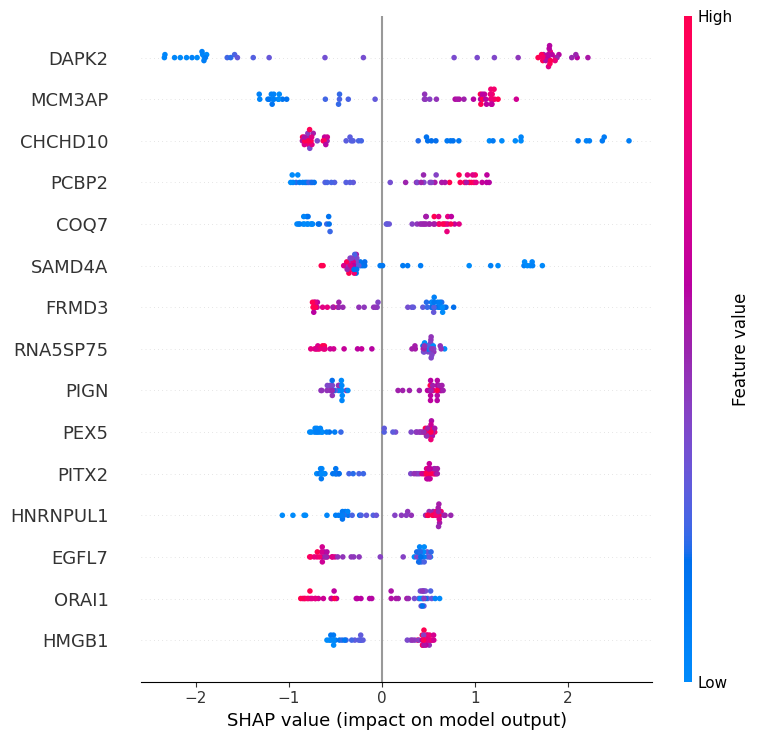

In [48]:
shap.summary_plot(shap_values, X_test, max_display=15)


In [45]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.6003804269405586